#  Partie 1 : Introduction au Dataset

In [1]:

import pandas as pd

In [2]:

df = pd.read_csv("/content/drive/MyDrive/archive/tested.csv")


In [3]:

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:

df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [5]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [6]:

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


 Partie 2 : Nettoyage des Données

In [7]:

mp = df.isnull().sum() / len(df) * 100
mp

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,20.574163
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.239234


In [8]:

sp = mp[mp > 40].index
df = df.drop(columns=sp)

In [9]:

numériques = df.select_dtypes(include=['int64','float64']).columns

In [10]:
for col in numériques:
    df[col] = df[col].fillna(df[col].mean())

In [11]:

categorical = df.select_dtypes(include=['object']).columns

In [12]:
for col in categorical:
    df[col] = df[col].fillna(df[col].mode()[0])

 Valeurs aberrantes (Outliers)

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

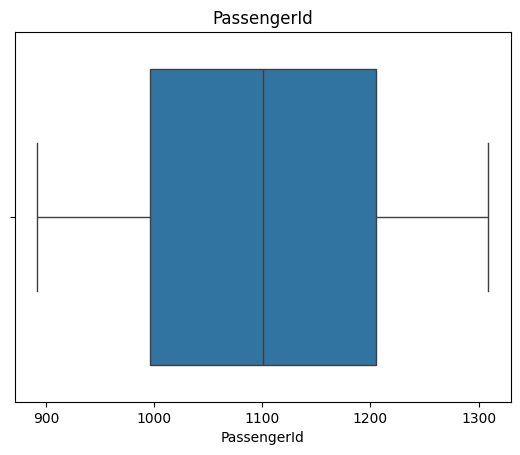

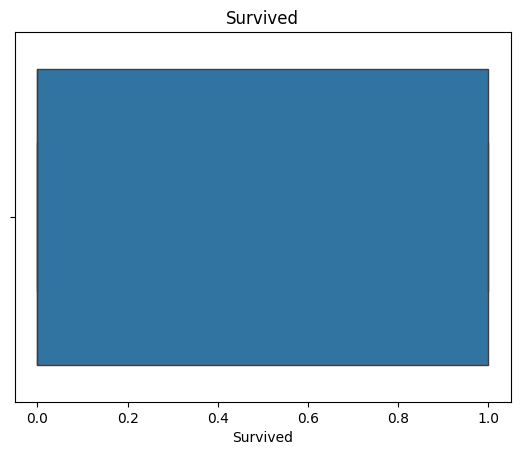

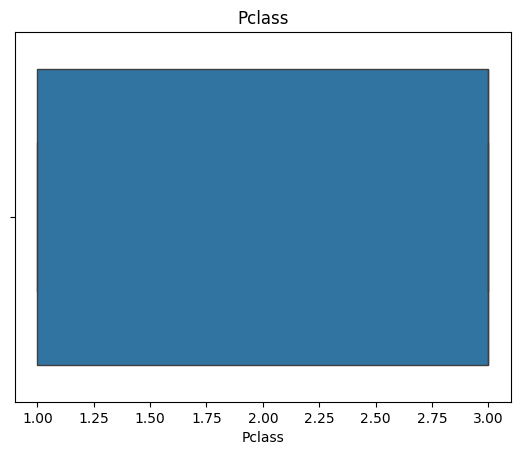

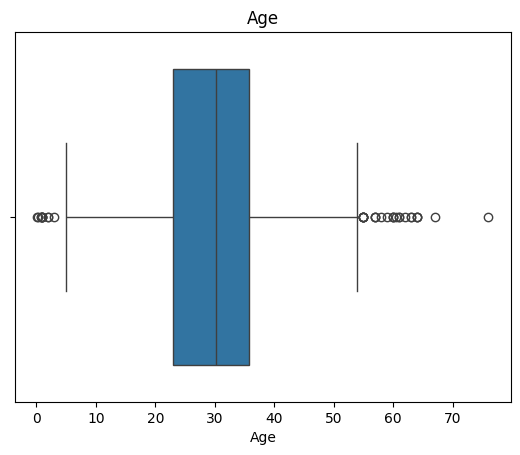

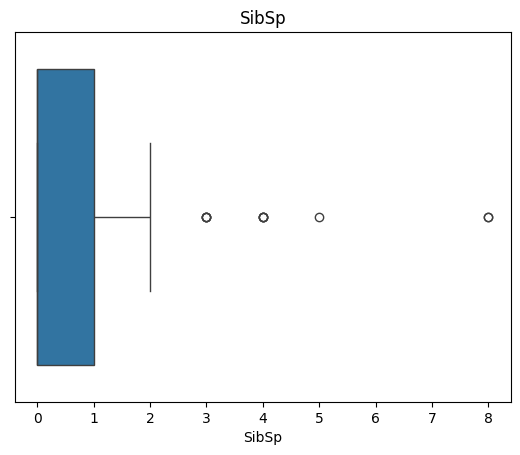

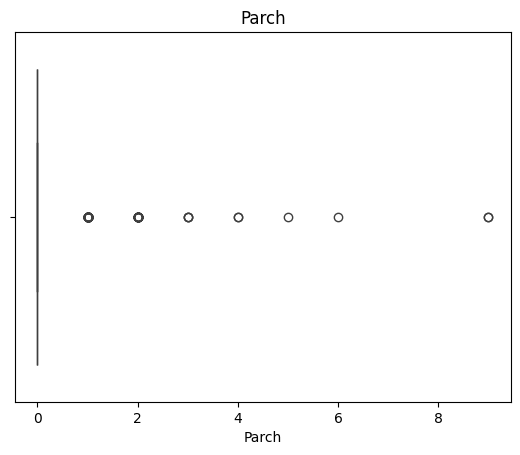

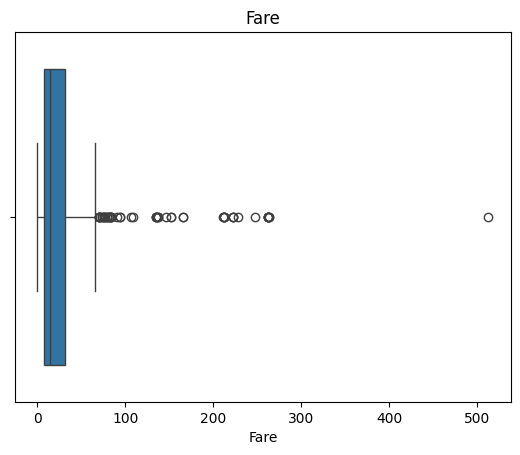

In [15]:

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


In [16]:

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR



    median = df[col].median()
    df.loc[(df[col] < lower) | (df[col] > upper), col] = median

/tmp/ipykernel_250/730553554.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1100.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[(df[col] < lower) | (df[col] > upper), col] = median


In [17]:

df = df[(df[col] >= lower) & (df[col] <= upper)]

 Partie 3 : Transformation des Données

In [18]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [19]:

categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')


In [20]:

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

In [21]:

df['Pclass'] = df['Pclass'].map({1:1, 2:2, 3:3})

In [22]:

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

In [23]:

scaler_minmax = MinMaxScaler()
df[numeric_cols] = scaler_minmax.fit_transform(df[numeric_cols])

In [24]:

scaler_std = StandardScaler()

df_standard = df.copy()
df_standard[numeric_cols] = scaler_std.fit_transform(df_standard[numeric_cols])

#  Partie 4 : Données Déséquilibrées

In [25]:

df['Survived'].value_counts()

,count
Survived,
0.0,266
1.0,152


In [26]:


from sklearn.utils import resample

maj = df[df['Survived'] == 0]
mino = df[df['Survived'] == 1]

maj_down = resample(maj, replace=False, n_samples=len(mino), random_state=42)

df_under = pd.concat([maj_down, mino])

df_under['Survived'].value_counts()

,count
Survived,
0.0,152
1.0,152


In [32]:
from imblearn.over_sampling import SMOTE

X = df.drop('Survived', axis=1)
X = df.drop(['Survived', 'Name', 'Ticket'], axis=1)
y = df['Survived']

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

pd.Series(y_res).value_counts()

,count
Survived,
0.0,266
1.0,266
